# ArgosQC WildlifeComputers Project Config


1. Connect to WildlifeComputers portal (requires access_key and secret_key pair)
2. Show a list of collaborator (tag owner) who shared projects with OTN.
3. Show/download selected raw tag data from WC portal. 
4. Map tag locations for observation.
5. Generate configuration files for ArgosQC.wc_qc().

In [1]:
from py_nrt import argos_wc_project_config as awpc
import itables

## 1. Connects to WildlifeComputers portal

### OTN data team for `access_key` (Access Key) and `secret_key` (Secret Key) for OTNDC account.

In [2]:
# Mandatory input
program = 'irap'

# Ask OTN DC for the keys.
access_key = 'S1dgiTTyS2WQuZVuexmoe2WG7Tb+F+AZvyZaWSLcj0I='
secret_key = '8jIqAZzTpd4GsT71NwLB0nkOnN8DRn1mkzT4xyOI2QQ='

# (Optional) leave it blank if project is not in OTN node.
otn_collection_code = ''

# Destination folder for wc_qc config files and tag downloads.
qc_input_path = r'input'

# Destination folder for wc_qc results: {qc_output_path}/{program}/{collaborator}_{common_name}
qc_output_path = 'qc'

# Set to True to see API payload and response.
verbose=False

## 2. Show a list of collaborator (tag owner) who shared projects with OTN

### Contact OTN data team if your collaborator is not in the list.

In [3]:
# Get all collaborators
collaborators_df, collaborator_id_widget = awpc.wc_get_collab_ids(a_key=access_key, s_key=secret_key, verbose=verbose)

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


Select a collaborator to proceed


RadioButtons(layout=Layout(width='600px'), options=('damian.lidgard@dal.ca - 558abcaea86a234b286bdc3e',), styl…

## 3. Show/download selected raw tag data from WC portal

### The goal of this cell is to identify a list of WC `tag_uuid`s in an OTN project:

#### 3.1 Find the project and WC tags in `otn_satellite_tags` table in OTN Node DB e.g.  

#### 3.2 Column mapping between  `otn_satellite_tags` table and tag information from WC portal.

`collectornumber` - `serial_number`

`ptt_code` - `ptt`

`instrumentmodel` - `tag_type`

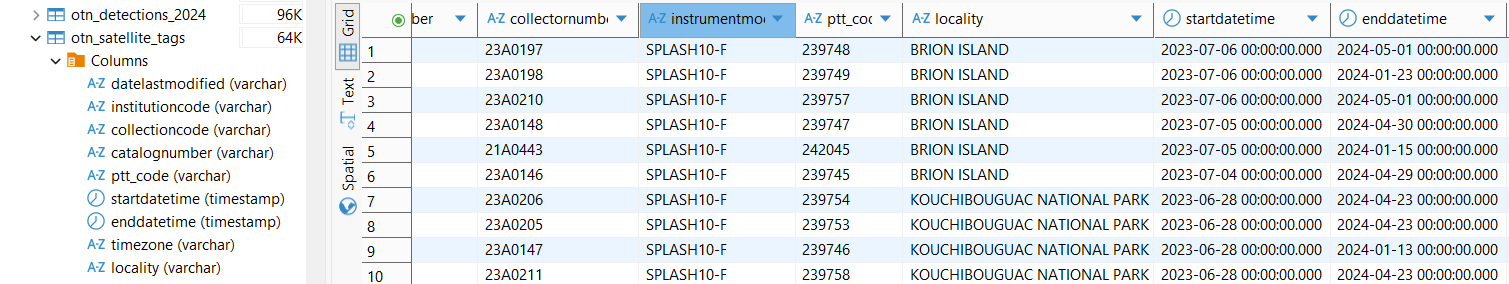

### 3.3 Take note of the list of WC `tag_uuid`s 

In [4]:
if collaborator_id_widget.value:
    deployment_df = awpc.get_deployments_for_owner_id(
        a_key=access_key, 
        s_key=secret_key, 
        collaborator=collaborator_id_widget.value, 
        verbose=verbose
    )
else:
    print('Please select a collaborator...')

Showing 56 tag(s) for collaborator: damian.lidgard@dal.ca - 558abcaea86a234b286bdc3e


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


### 3.4 (Optional) Download Selected Tag for Observation
### Note: ptt is reusable; tag UUID is the uinque identifier

In [5]:
raw_track_df=awpc.download_tag(
    a_key=access_key, 
    s_key=secret_key, 
    deployment_df=deployment_df, 
    program=program,
    qc_input_path=qc_input_path,
    verbose=verbose
)

Combobox(value='', options=('5f90d1ad17e84815885608c1', '60085a1517e84815e4b95f34', '69c2aff03b8cd97be60854eb'…

Button(button_style='primary', description='Download', style=ButtonStyle())

Downloading: 65b902b83caf33c4780bbfbd...
Downloaded to: "input\irap\irap_damianlidgard\65b902b83caf33c4780bbfbd.zip
Successfully unzipped to: "input\irap\irap_damianlidgard\65b902b83caf33c4780bbfbd"
Extracted 17 files
Extracted raw track for 65b902b83caf33c4780bbfbd


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## 4. Visualize the Latest Location (Export csv from 3.3) for all Tags or Track for One Tag (Export csv from 3.4)
4.1 Click the `CSV` button in 3.3 or 3.4. Find downloaded `<collaborator>_latest_<yyyymmdd>.csv` or `<tag_uuid>_track__<yyyymmdd>.csv`

4.2 Go to a kepler.gl viewer instance https://kepler.gl/demo or http://localhost:8000/ via SSH tunnel to JPhub

`ssh -L 8000:localhost:8000  -i <your_ssl_pk_file> <your_user>@jphub.oceantrack.org`

See https://gitlab.oceantrack.org/otn-partner-nodes/jphub/-/wikis/Host-and-Use-Kepler.gl-Viewer-on-JPhub

4.3 Upload data `<collaborator>_latest_<yyyymmdd>.csv` or `<tag_uuid>_track__<yyyymmdd>.csv`

4.4 Click `Add Layer`: under `Basic` select `Point`; under `Color based on` select `tag_ref`

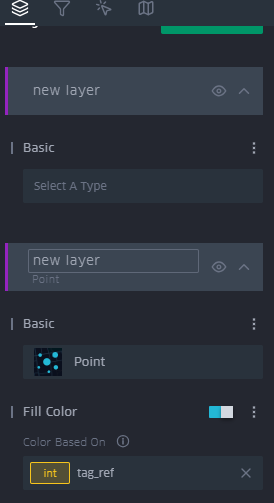

4.5 In Filters tab, click `Add Filter` select `date_time`
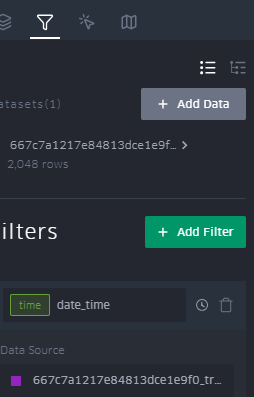

4.6 Adjust rolling window and click the play button

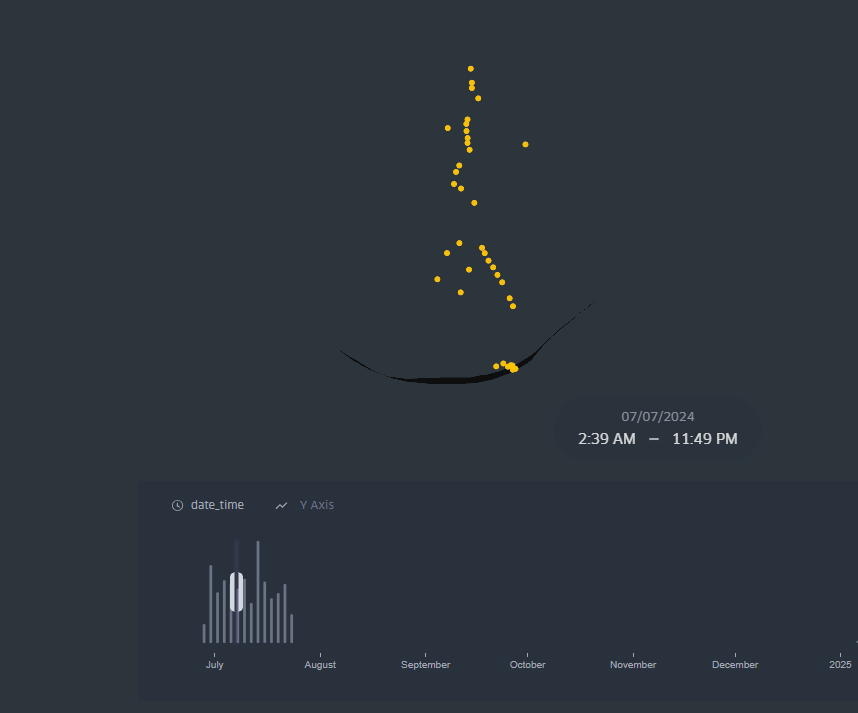

## 5. Generate WC_QC Configuration Files

### All Configuration Parameters for SSM Model and QC Process See: 

1. Node Manager Training: 

https://github.com/ocean-tracking-network/node-manager-training/blob/nrt-ArgosQC/_episodes/30_near_real_time_qc_process.md

2. ArgosQC vignette: 

https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/SMRU_config_file.Rmd

https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/WC_workflow.Rmd

### Required Parameters:
#### `time_step` (hours): adjust value (usually between 1 to 10) according to tagged animal's species.
#### `common_name` and `species`
#### A list of tag_uuid_list


### Observe and Modify Configuration File(s) as Needed

- Example configuration file (json):

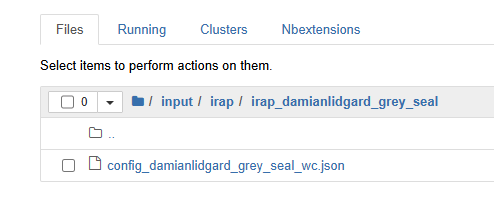


In [6]:
# Default settings
time_step = 3

# Project specific settings
common_name = 'grey seal'
species = 'Halichoerus grypus'
release_site = 'BRION ISLAND'
state_country = 'Canada'

tag_uuid_list = ['65b902b53caf33c4780bbfb8', '65b902b2d1123fd50006e6c3']

awpc.create_wc_qc_config(
    program = program,
    collaborator=collaborator_id_widget.value,
    tag_uuid_list=tag_uuid_list,
    otn_collection_code=otn_collection_code,
    qc_input_path=qc_input_path,
    qc_output_path=qc_output_path,
    a_key=access_key, 
    s_key=secret_key, 
    timeout=180,
    time_step=time_step,
    common_name=common_name,
    species=species,
    release_site=release_site,
    state_country=state_country,
    verbose=verbose
)


wc_qc config file is written to input/irap/irap_irap_damianlidgard_grey_seal/config_irap_damianlidgard_grey_seal_wc.json


## 6. Next Step: Run ArgosQC for Configured Project

### Option 1:  `ArgosQC_WildlifeComputers` R-Notebook

- Replace config = "<smru_config_file.json>" with the above output path for `smru_qc config file`
```
library(ArgosQC)
library(pathroutr)
wd_qc(
  wd = ".",
  config = "<wc_qc_config_file.json>"
)
```

### Option 2: In RStudio (Local or Server)

- Instructions: https://github.com/ianjonsen/ArgosQC?tab=readme-ov-file#installation


## 7. Evaluate ArgosQC Resluts

### After smru_qc is done find ssm output file in qc/\<program>/\<program>_\<cid>/

e.g. qc/irap/iraq_damianlidgard/ssmoutputs\*_nrt.csv

In [7]:
subset_tags = [ '65b902b2d1123fd50006e6c3']
tag_ssmoutput_df = awpc.extract_ssmoutput_tracks(program, collaborator_id_widget.value, common_name, qc_output_path, subset_tags, verbose=verbose)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## 8. Visualize SSM Output with Raw Tracks - Helps to Verify and Improve Model Perforamce

8.1 Click the CSV button in above cell and download \<tag_owner\>_\<common_name\>_ssmoutput_<yyyymmdd>.csv

8.2 Upload SSM output csv in the same kepler.gl viewer.
    
8.3 Add a Point Layer and Fill Color by `tag_ref`
    
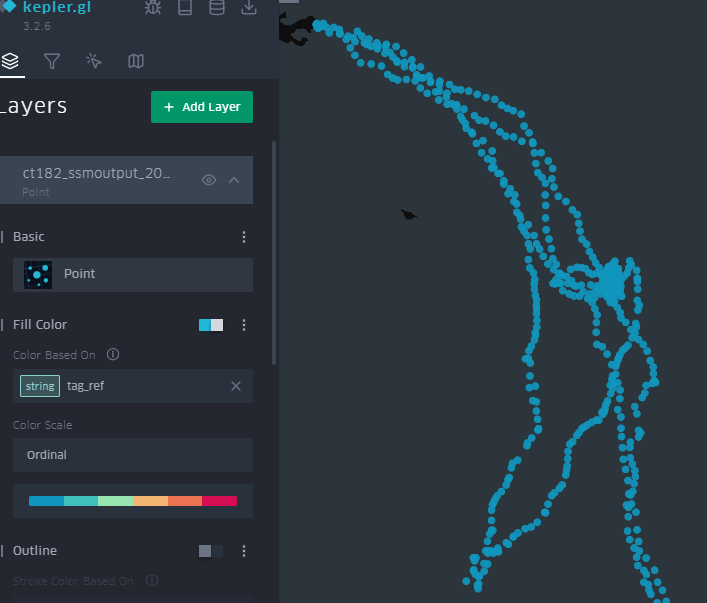
    
8.4 Toggle raw and ssmoutput layers for static observation
    
 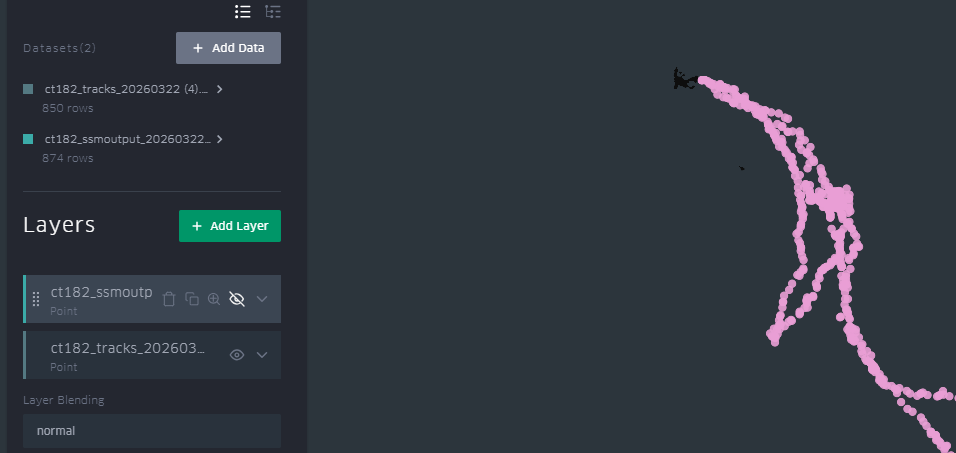
    
8.4 In Filters tab click Synced datasets and select <cid>_ssmoutput_<yyyymmdd>.csv
    
 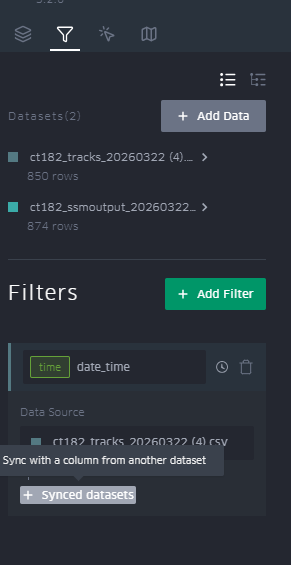
    
8.5 Adjust sliding window on the bottom and compare raw and QCed animal locations over time.
    
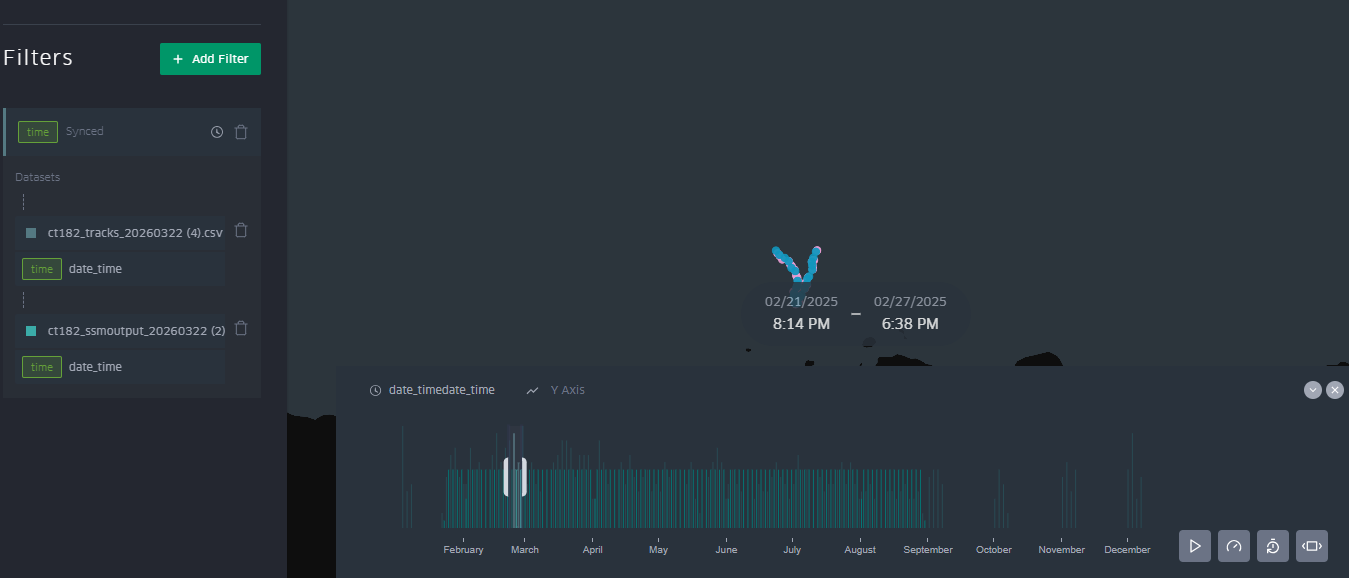